# Phase 6 Rolling 5-Year CAGR - Exploratory Analysis

This notebook does the first two EDA passes on the Phase 6 rolling CAGR table:

1. **Univariate distribution checks** - summary stats, histograms, and boxplots for each factor's CAGR across the 20 rolling slots.
2. **Time series of the rolling CAGR** - how each factor's annualized 5-year growth has moved as the rolling window shifts from `2001-2006` through `2020-2025`.

Source file: `outputs/phase6/phase6_eps_rolling_five_year_cagr.csv`.

All charts here are exploratory - no new data is generated and the Phase 6 outputs are not modified.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PHASE6_PATH = ROOT / "outputs" / "phase6" / "phase6_eps_rolling_five_year_cagr.csv"

df = pd.read_csv(PHASE6_PATH)

CAGR_COLUMNS = [
    "revenue_cagr",
    "net_income_cagr",
    "shares_cagr",
    "net_margin_cagr",
    "rev_per_share_cagr",
    "eps_cagr",
]
CAGR_LABELS = {
    "revenue_cagr": "Revenue",
    "net_income_cagr": "Net Income",
    "shares_cagr": "Shares",
    "net_margin_cagr": "Net Margin",
    "rev_per_share_cagr": "Rev/S",
    "eps_cagr": "EPS",
}
FACTOR_COLORS = {
    "revenue_cagr": "#2E86AB",
    "net_income_cagr": "#A23B72",
    "shares_cagr": "#F18F01",
    "net_margin_cagr": "#3B8686",
    "rev_per_share_cagr": "#6C5B9B",
    "eps_cagr": "#C73E1D",
}

for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    if _style in plt.style.available:
        plt.style.use(_style)
        break
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "axes.labelcolor": "#333333",
    "axes.edgecolor": "#CCCCCC",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "grid.color": "#E5E5E5",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 10,
})

def style_axis(ax, *, zero_line=True):
    if zero_line:
        ax.axhline(0, color="#999999", linewidth=0.8, zorder=0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.tick_params(axis="both", length=0)

print(f"Loaded {len(df)} rolling slots from {PHASE6_PATH.relative_to(ROOT)}")
df[["slot", "start_year", "end_year"] + CAGR_COLUMNS]

Loaded 20 rolling slots from outputs/phase6/phase6_eps_rolling_five_year_cagr.csv


,slot,start_year,end_year,revenue_cagr,net_income_cagr,shares_cagr,net_margin_cagr,rev_per_share_cagr,eps_cagr
0,2001-2006,2001,2006,1.616812,2.379129,0.106322,0.291315,1.365327,2.054382
1,2002-2007,2002,2007,1.067268,1.113616,0.074635,0.022420,0.923693,0.966822
2,2003-2008,2003,2008,0.715737,1.091372,0.043490,0.218935,0.644229,1.004208
3,2004-2009,2004,2009,0.492902,0.748377,0.032068,0.171126,0.446515,0.694051
4,2005-2010,2005,2010,0.367170,0.421490,0.020631,0.039732,0.339533,0.392756
5,2006-2011,2006,2011,0.290143,0.259062,0.011162,-0.024092,0.275901,0.245163
6,2007-2012,2007,2012,0.247692,0.206285,0.009979,-0.033187,0.235364,0.194366
7,2008-2013,2008,2013,0.205632,0.246759,0.013068,0.034113,0.190081,0.230677
8,2009-2014,2009,2014,0.227840,0.167373,0.841628,-0.049246,-0.333286,-0.366119
9,2010-2015,2010,2015,0.206601,0.139615,0.845992,-0.055517,-0.346367,-0.382655


## 1. Univariate distribution checks

For each of the six `*_cagr` columns across all 20 rolling slots, look at:

- **Summary statistics** (mean, median, std, min, max) to compare level and volatility
- **Histograms** to see distribution shape
- **Boxplots** to compare spread and outliers across factors in one view

In [2]:
stats = (
    df[CAGR_COLUMNS]
    .agg(["mean", "median", "std", "min", "max"])
    .T
    .rename(index=CAGR_LABELS)
)
stats["range"] = stats["max"] - stats["min"]

(
    stats.style
    .format("{:.1%}")
    .background_gradient(cmap="Blues", subset=["mean", "median"])
    .background_gradient(cmap="Oranges", subset=["std", "range"])
    .set_caption("Rolling 5-year CAGR: summary stats across 20 slots")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "600"), ("padding", "8px"), ("color", "#333")]},
        {"selector": "th", "props": [("background-color", "#F5F5F5"), ("color", "#333"), ("font-weight", "600")]},
    ])
)

,mean,median,std,min,max,range
Revenue,36.7%,20.6%,37.0%,16.7%,161.7%,145.0%
Net Income,44.6%,24.3%,54.3%,3.4%,237.9%,234.6%
Shares,22.2%,1.7%,36.8%,-2.3%,84.6%,86.9%
Net Margin,4.1%,1.8%,9.9%,-11.8%,29.1%,40.9%
Rev/S,20.6%,19.9%,44.0%,-36.3%,136.5%,172.8%
EPS,28.7%,23.8%,58.8%,-43.8%,205.4%,249.3%


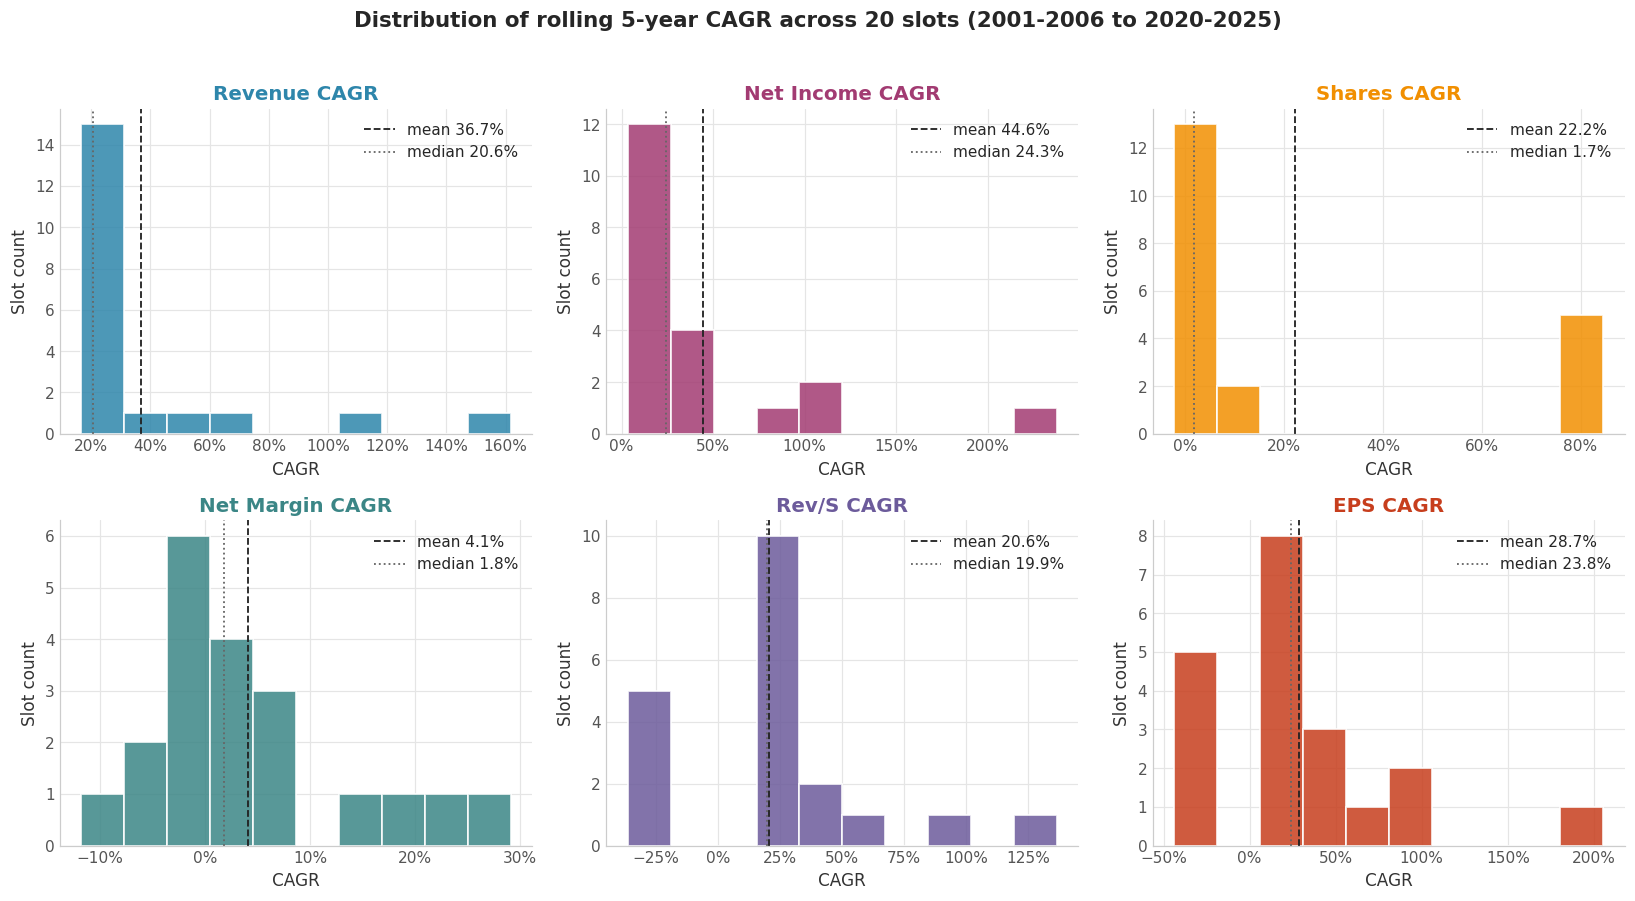

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, column in zip(axes, CAGR_COLUMNS):
    values = df[column] * 100
    color = FACTOR_COLORS[column]
    ax.hist(values, bins=10, color=color, edgecolor="white", alpha=0.85, linewidth=1.2)
    ax.axvline(values.mean(), linestyle="--", color="#222222", linewidth=1.2, label=f"mean {values.mean():.1f}%")
    ax.axvline(values.median(), linestyle=":", color="#666666", linewidth=1.2, label=f"median {values.median():.1f}%")
    ax.set_title(f"{CAGR_LABELS[column]} CAGR", color=color)
    ax.set_xlabel("CAGR")
    ax.set_ylabel("Slot count")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.tick_params(axis="both", length=0)
    ax.legend(loc="upper right")

fig.suptitle(
    "Distribution of rolling 5-year CAGR across 20 slots (2001-2006 to 2020-2025)",
    fontsize=14, fontweight="semibold", y=1.02,
)
fig.tight_layout()
plt.show()

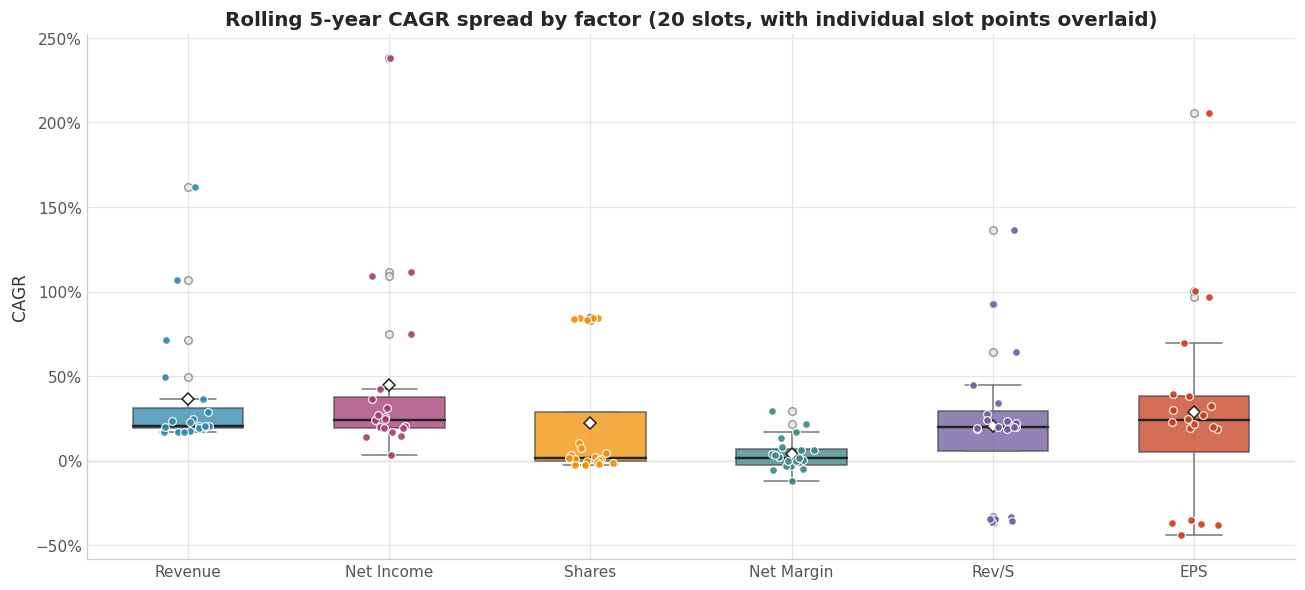

In [4]:
fig, ax = plt.subplots(figsize=(12, 5.5))

box_data = [df[column] * 100 for column in CAGR_COLUMNS]
positions = np.arange(len(CAGR_COLUMNS))

bp = ax.boxplot(
    box_data,
    positions=positions,
    widths=0.55,
    patch_artist=True,
    showmeans=True,
    medianprops={"color": "#222222", "linewidth": 1.6},
    meanprops={"marker": "D", "markerfacecolor": "#FFFFFF", "markeredgecolor": "#222222", "markersize": 6},
    whiskerprops={"color": "#777777", "linewidth": 1.0},
    capprops={"color": "#777777", "linewidth": 1.0},
    flierprops={"marker": "o", "markerfacecolor": "#E6E6E6", "markeredgecolor": "#888888", "markersize": 5, "alpha": 0.8},
)

for patch, column in zip(bp["boxes"], CAGR_COLUMNS):
    patch.set_facecolor(FACTOR_COLORS[column])
    patch.set_alpha(0.75)
    patch.set_edgecolor("#444444")
    patch.set_linewidth(1.0)

for idx, column in enumerate(CAGR_COLUMNS):
    jitter = np.random.default_rng(seed=idx).uniform(-0.12, 0.12, size=len(df))
    ax.scatter(
        positions[idx] + jitter,
        df[column] * 100,
        color=FACTOR_COLORS[column],
        edgecolor="white",
        s=26,
        linewidth=0.8,
        alpha=0.9,
        zorder=3,
    )

ax.set_xticks(positions)
ax.set_xticklabels([CAGR_LABELS[c] for c in CAGR_COLUMNS])
ax.set_ylabel("CAGR")
ax.set_title("Rolling 5-year CAGR spread by factor (20 slots, with individual slot points overlaid)")
style_axis(ax)

fig.tight_layout()
plt.show()

## 2. Time series of the rolling CAGR

Plot each factor's 5-year CAGR against the slot's `end_year`, so each point answers "as of year X, what was the annualized growth over the prior 5 years?"

Three views:

- Combined line chart with all six factors
- Small-multiples view so each factor has its own axis
- Slot-over-slot delta (second-derivative view) to flag inflection points

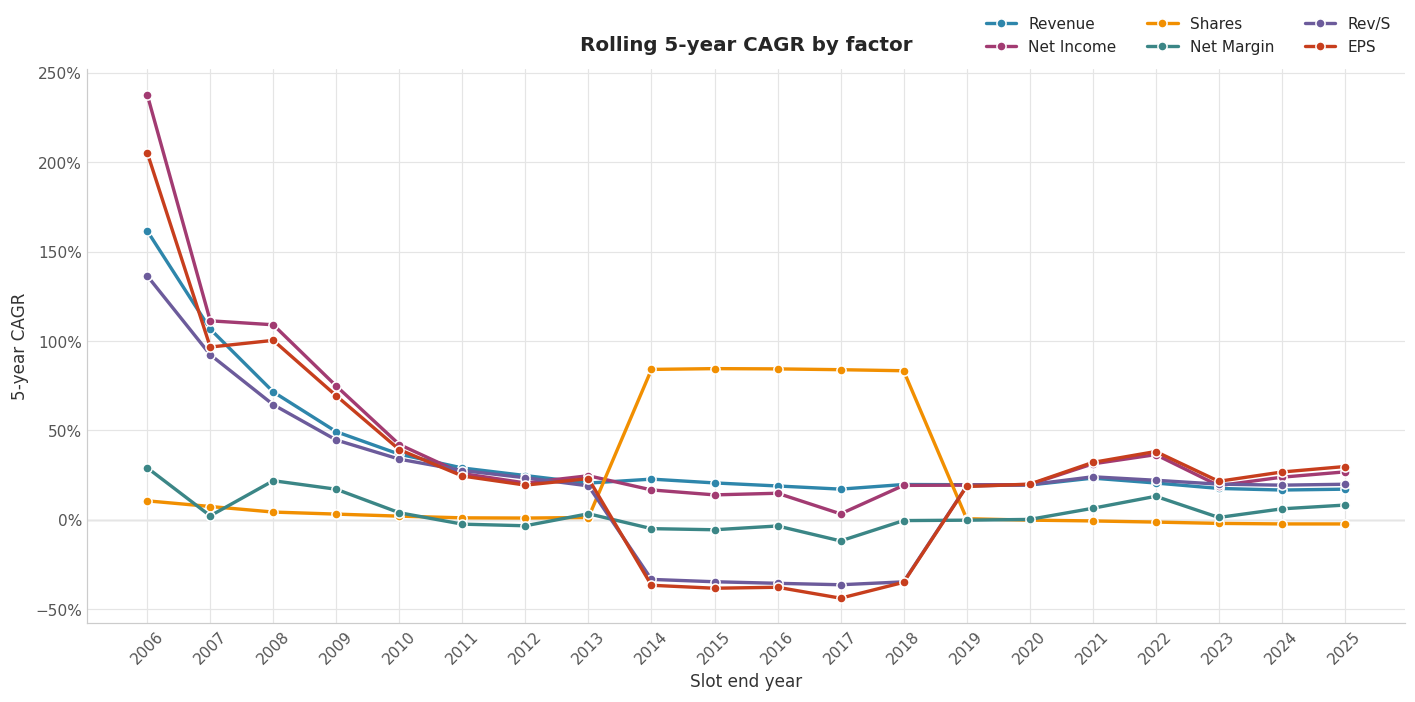

In [5]:
fig, ax = plt.subplots(figsize=(13, 6.5))

for column in CAGR_COLUMNS:
    ax.plot(
        df["end_year"],
        df[column] * 100,
        marker="o",
        markersize=6,
        linewidth=2.2,
        color=FACTOR_COLORS[column],
        label=CAGR_LABELS[column],
        markeredgecolor="white",
        markeredgewidth=1.0,
    )

ax.set_xlabel("Slot end year")
ax.set_ylabel("5-year CAGR")
ax.set_title("Rolling 5-year CAGR by factor", pad=12)
ax.set_xticks(df["end_year"])
ax.tick_params(axis="x", rotation=45)
style_axis(ax)
ax.legend(
    loc="upper right",
    ncol=3,
    bbox_to_anchor=(1.0, 1.12),
    frameon=False,
)

fig.tight_layout()
plt.show()

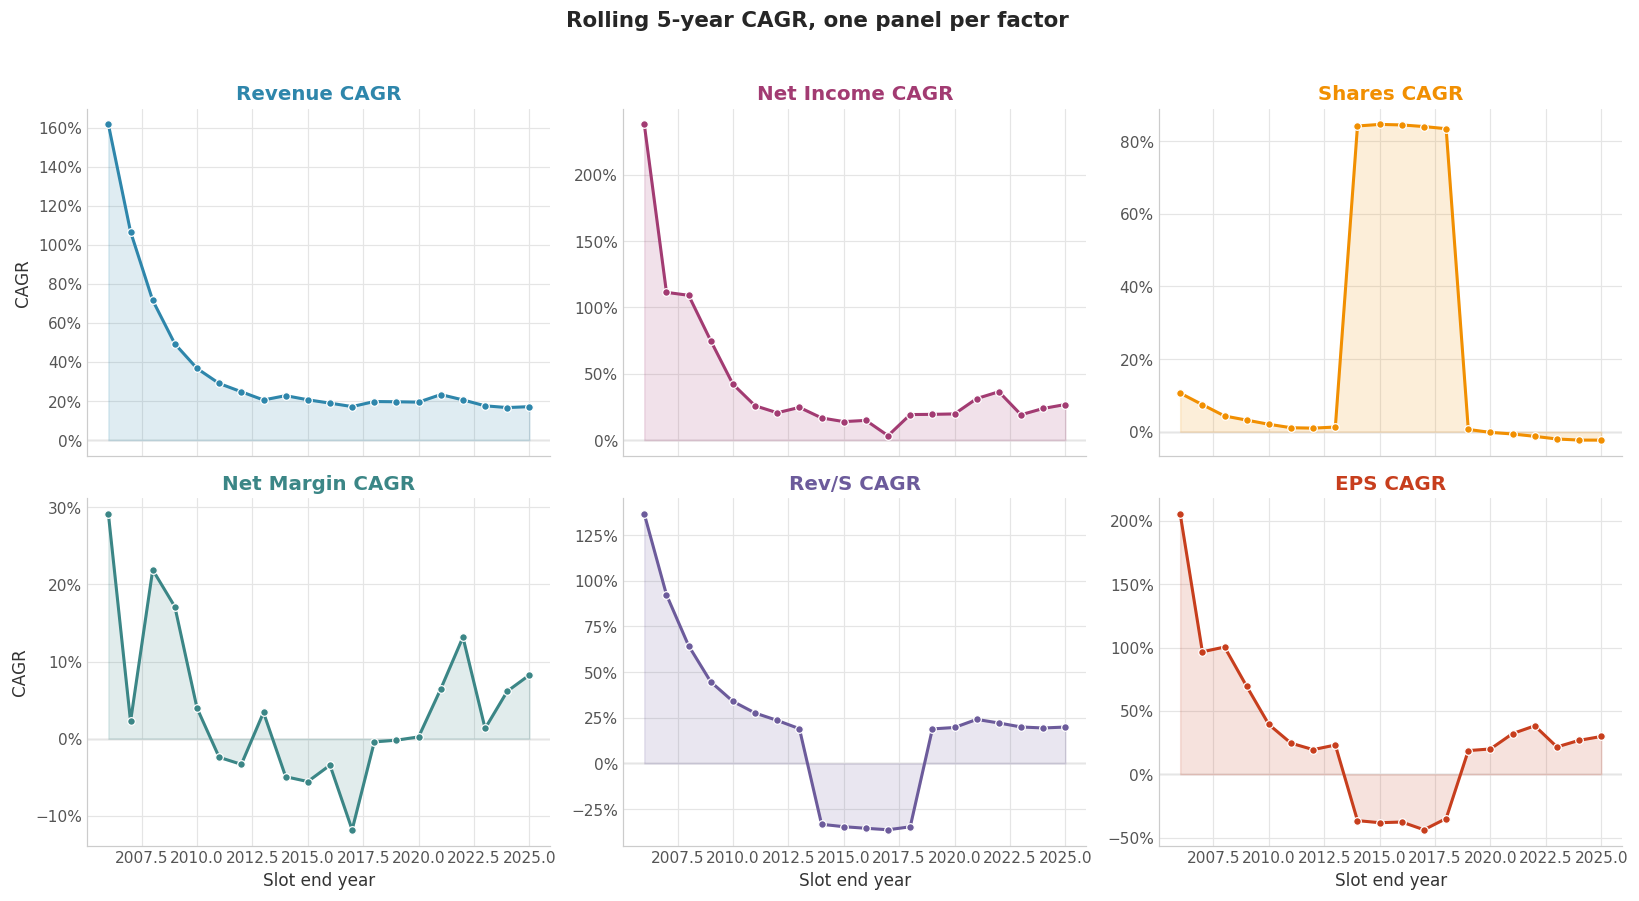

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for ax, column in zip(axes, CAGR_COLUMNS):
    color = FACTOR_COLORS[column]
    series = df[column] * 100
    ax.fill_between(df["end_year"], 0, series, color=color, alpha=0.15, zorder=1)
    ax.plot(
        df["end_year"], series,
        marker="o", markersize=5, linewidth=2.0,
        color=color, markeredgecolor="white", markeredgewidth=0.8,
        zorder=2,
    )
    ax.set_title(f"{CAGR_LABELS[column]} CAGR", color=color)
    style_axis(ax)

for ax in axes[-3:]:
    ax.set_xlabel("Slot end year")
for ax in axes[::3]:
    ax.set_ylabel("CAGR")

fig.suptitle("Rolling 5-year CAGR, one panel per factor", fontsize=14, fontweight="semibold", y=1.02)
fig.tight_layout()
plt.show()

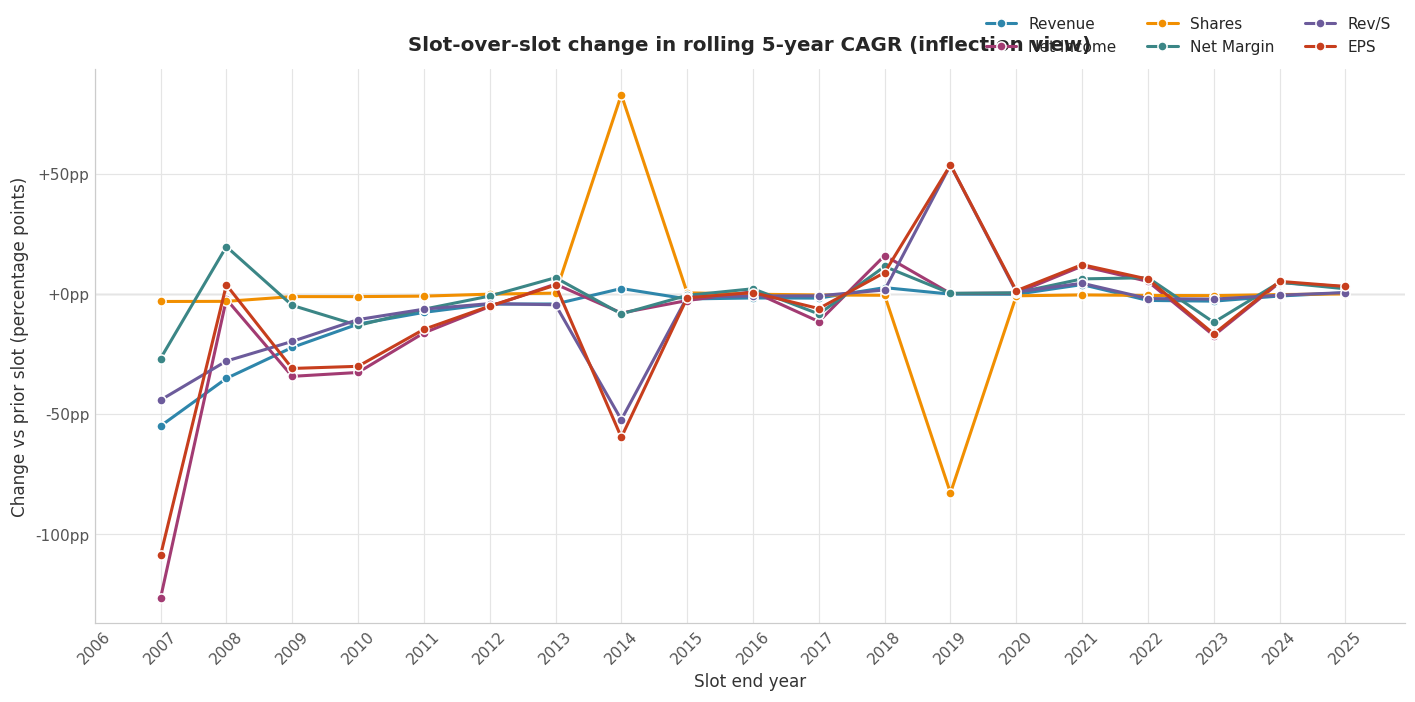

,end_year,revenue_cagr,net_income_cagr,shares_cagr,net_margin_cagr,rev_per_share_cagr,eps_cagr
0,2006,NaN,NaN,NaN,NaN,NaN,NaN
1,2007,-54.954427,-126.551338,-3.168648,-26.889525,-44.163400,-108.756056
2,2008,-35.153116,-2.224396,-3.114489,19.651526,-27.946400,3.738655
3,2009,-22.283480,-34.299525,-1.142175,-4.780895,-19.771442,-31.015740
4,2010,-12.573227,-32.688670,-1.143714,-13.139432,-10.698112,-30.129547


In [7]:
delta_df = df[["end_year"]].copy()
for column in CAGR_COLUMNS:
    delta_df[column] = df[column].diff() * 100

fig, ax = plt.subplots(figsize=(13, 6.5))

for column in CAGR_COLUMNS:
    ax.plot(
        delta_df["end_year"],
        delta_df[column],
        marker="o",
        markersize=6,
        linewidth=2.0,
        color=FACTOR_COLORS[column],
        label=CAGR_LABELS[column],
        markeredgecolor="white",
        markeredgewidth=1.0,
    )

ax.set_xlabel("Slot end year")
ax.set_ylabel("Change vs prior slot (percentage points)")
ax.set_title("Slot-over-slot change in rolling 5-year CAGR (inflection view)", pad=12)
ax.set_xticks(delta_df["end_year"])
ax.tick_params(axis="x", rotation=45)
ax.axhline(0, color="#999999", linewidth=0.8, zorder=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _pos: f"{v:+.0f}pp"))
ax.tick_params(axis="both", length=0)
ax.legend(
    loc="upper right",
    ncol=3,
    bbox_to_anchor=(1.0, 1.12),
    frameon=False,
)

fig.tight_layout()
plt.show()

delta_df.head()

## Quick observations

Things to look for in the charts above:

- **Revenue CAGR** steadily decays from the early 2000s high-growth slots down toward the high-teens in the most recent windows - classic maturation curve.
- **Net Margin CAGR** is volatile and swings above/below zero, meaning the margin itself has expanded and compressed depending on which 5-year window you pick.
- **Shares CAGR** and **EPS CAGR** show a clean discontinuity for slots that span the 2013-2014 share-basis break - these are the slots to caveat in any narrative.
- Any slot where the slot-over-slot delta chart shows a large jump is a good candidate for deeper Phase 4 / Phase 5 drill-down to explain why.